# Introduction: Fixed Points as Layers

The entry point is the equation

$$
z^\star=f_\theta(z^\star,x).
$$

The symbol $x$ is the external stimulus and $z^\star$ is the hidden state
that is consistent with the transition $f_\theta$. A finite neural network
layer applies a map once. A deep equilibrium layer asks for the state that would
remain unchanged if the map were applied again.

This notebook follows the introduction theme from the Deep Implicit Layers
tutorial and runs it through the `silva_networks` solver API.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [3](https://jseluis.github.io/silva-networks/paper/references/#ref-3), [41](https://jseluis.github.io/silva-networks/paper/references/#ref-41). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import resolve_device, SolverConfig

torch.manual_seed(7)
np.random.seed(7)
device = resolve_device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Scalar Warm-Up

Start with a scalar contraction:

$$
f(z)=\tanh(az+b),\qquad |a|<1.
$$

The Picard step with damping is

$$
z_{k+1}=(1-\alpha)z_k+\alpha f(z_k).
$$

The residual at step $k$ is

$$
r_k=|f(z_k)-z_k|.
$$

In [3]:
from silva_networks import fixed_point, silva_residual_ratio

a = torch.tensor(0.55, device=device)
b = torch.tensor(0.25, device=device)
z0 = torch.zeros((), device=device)

def scalar_f(z):
    return torch.tanh(a * z + b)

configs = [
    SolverConfig(solver="picard", max_iter=25, alpha=0.8),
    SolverConfig(solver="anderson", max_iter=12, alpha=0.8, history=4),
    SolverConfig(solver="broyden", max_iter=12, alpha=0.8),
]

solves = {cfg.solver: fixed_point(scalar_f, z0, cfg) for cfg in configs}
[(name, float(result.z.detach().cpu()), result.iterations, result.residual) for name, result in solves.items()]

[('picard', 0.4678535759449005, 22, 8.344650268554688e-07),
 ('anderson', 0.467959463596344, 12, 6.768107414245605e-05),
 ('broyden', 0.46785327792167664, 12, 1.1920928955078125e-06)]

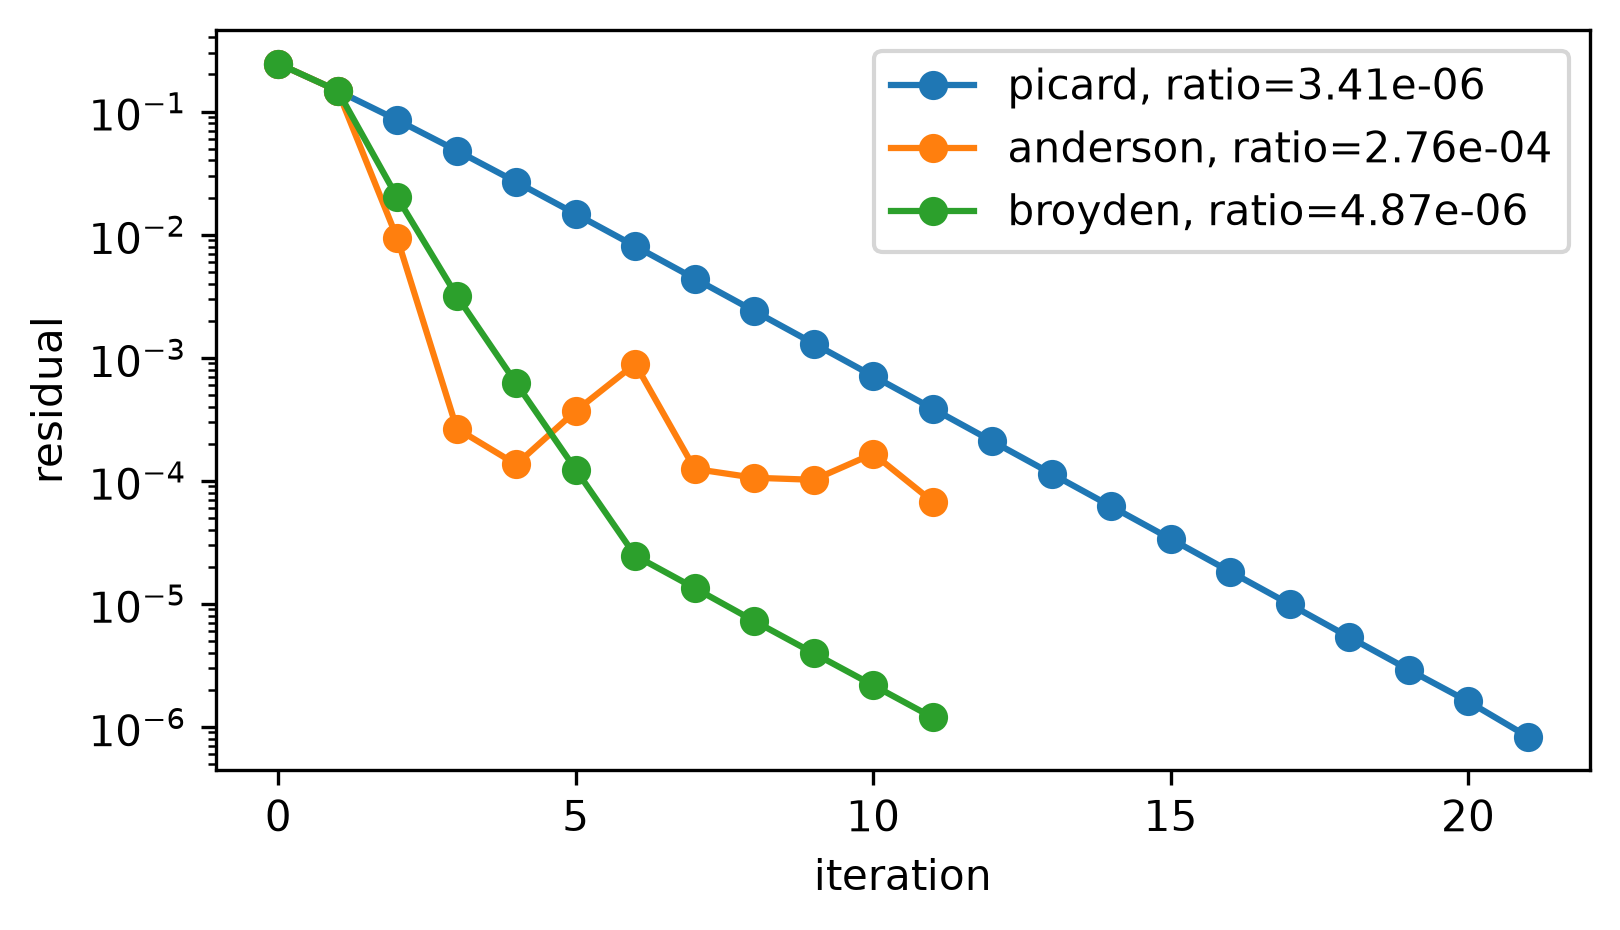

In [4]:
plt.figure(figsize=(5.5, 3.2))
for name, result in solves.items():
    plt.plot(result.residuals, marker="o", label=f"{name}, ratio={silva_residual_ratio(result.residuals):.2e}")
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("residual")
plt.legend()
plt.tight_layout()

## Package Fixed-Point Block

The scalar map becomes a vector map by replacing $a$ with $W_z$, $b$ with
an input-dependent term, and solving

$$
z^\star=\tanh(W_z z^\star + W_x x + b).
$$

`silva_fixed_point_block` exposes this equation directly.

In [5]:
from silva_networks import silva_fixed_point_block

x = torch.randn(8, 3, device=device)
block = silva_fixed_point_block(
    in_dim=3,
    state_dim=6,
    config=SolverConfig(solver="anderson", max_iter=8, alpha=0.7, history=3),
).to(device)

result = block(x, return_result=True)
result.z.shape, result.iterations, result.residuals[:3], result.residual

(torch.Size([8, 6]),
 8,
 [3.9145517349243164, 1.477637767791748, 0.5999192595481873],
 0.003611351130530238)

## A Tiny Classifier

The equilibrium state can feed an ordinary PyTorch head:

$$
\hat y = W_o z^\star + c.
$$

The code below uses a synthetic two-class task so the notebook is quick on CPU
and also runs unchanged on a Colab GPU runtime.

In [6]:
from silva_networks import silva_fixed_point_classifier

x_train = torch.randn(32, 4, device=device)
y_train = (x_train[:, 0] + 0.5 * x_train[:, 1] > 0).long()
model = silva_fixed_point_classifier(
    in_features=4,
    state_dim=12,
    num_classes=2,
    config=SolverConfig(solver="picard", max_iter=8, alpha=0.6),
).to(device)
optim = torch.optim.Adam(model.parameters(), lr=0.03)

losses = []
for _ in range(8):
    optim.zero_grad()
    logits = model(x_train)
    loss = torch.nn.functional.cross_entropy(logits, y_train)
    loss.backward()
    optim.step()
    losses.append(float(loss.detach().cpu()))

losses[:3], losses[-1]

([0.6417015194892883, 0.5284569263458252, 0.4128044843673706],
 0.06701552867889404)

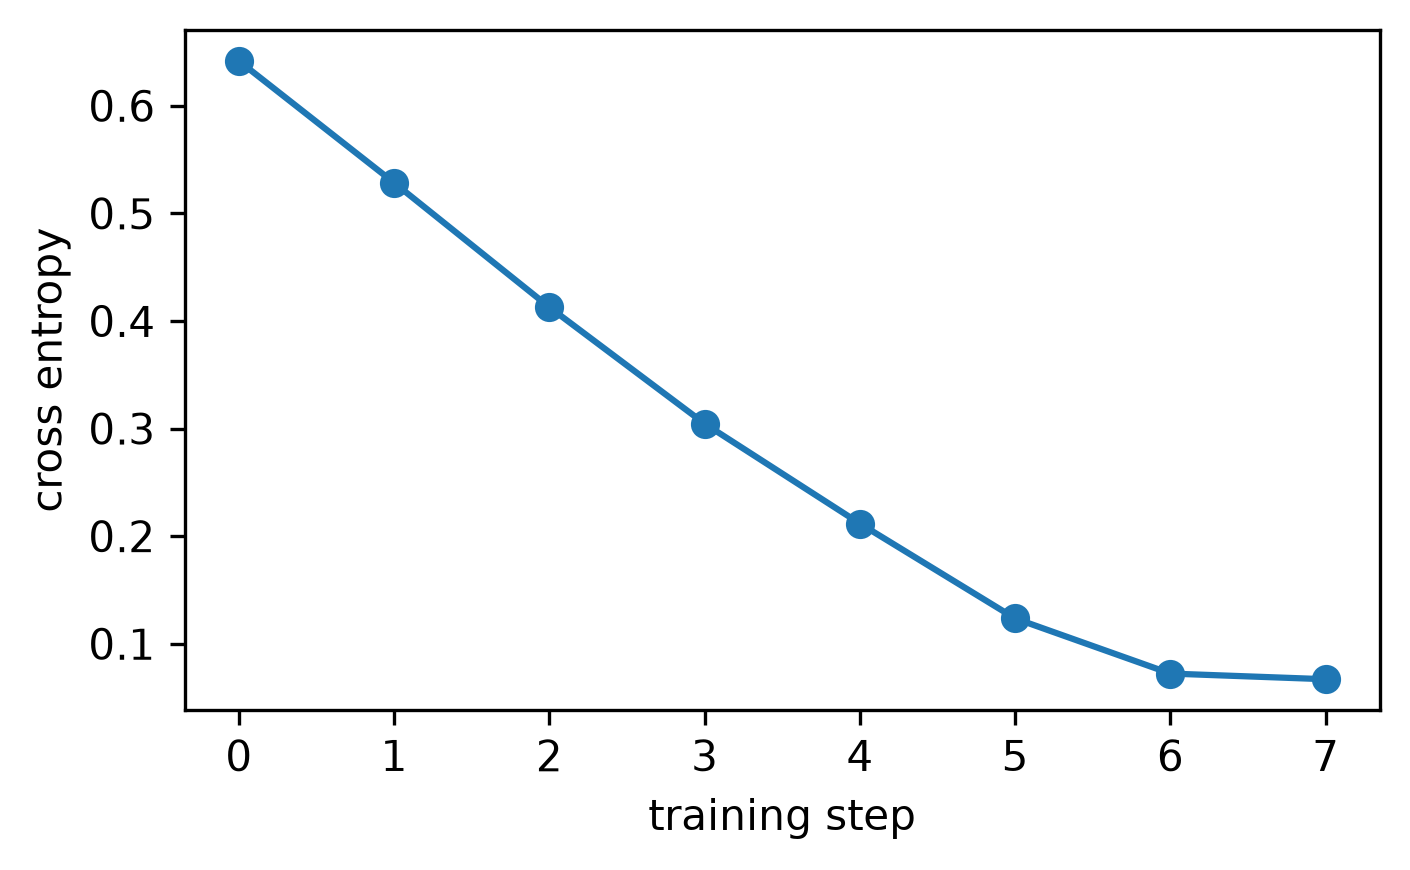

In [7]:
plt.figure(figsize=(4.8, 3.0))
plt.plot(losses, marker="o")
plt.xlabel("training step")
plt.ylabel("cross entropy")
plt.tight_layout()

## Citation and Sources

If this package or notebook is used, cite the software repository:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.1.0. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770098
```

When the work is connected to the SILVA methodology, cite the SILVA Networks
paper as well:

```text
Jose Luis Lima de Jesus Silva. SILVA Networks as Structured Implicit Layers and
Vector Attractors via Dynamic Interaction Fields. 2026. arXiv:2607.28989.
https://arxiv.org/abs/2607.28989
```

Background sources:

- Deep Implicit Layers tutorial: https://implicit-layers-tutorial.org/
- LocusLab DEQ repository: https://github.com/locuslab/deq
- Deep Equilibrium Models: https://arxiv.org/abs/1909.01377
- Multiscale Deep Equilibrium Models: https://arxiv.org/abs/2006.08656
- Stabilizing Equilibrium Models by Jacobian Regularization: https://arxiv.org/abs/2106.14342

The notebook is adapted to the `silva_networks` public API. It links to the
sources above and keep the examples package-native.

## From 01 Introduction Fixed Points to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the latent vector or tensor z |
| Condition | the injected observation x |
| Repeated computation | the tied map f_theta(z, x) |
| Required invariants | state shape and a decreasing or bounded residual |
| Replaceable components | transition, damping, stopping rule, backward solver, and readout |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [8]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**distance to an analytic fixed point and final relative residual**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **latent width, solver tolerance, and iteration budget**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [9]:
notebook_reproduction_record = {
    "notebook": '01_introduction_fixed_points.ipynb',
    "state": 'the latent vector or tensor z',
    "condition": 'the injected observation x',
    "transition": 'the tied map f_theta(z, x)',
    "invariants": 'state shape and a decreasing or bounded residual',
    "compact_metric": 'distance to an analytic fixed point and final relative residual',
    "scale_axis": 'latent width, solver tolerance, and iteration budget',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '01_introduction_fixed_points.ipynb',
 'state': 'the latent vector or tensor z',
 'condition': 'the injected observation x',
 'transition': 'the tied map f_theta(z, x)',
 'invariants': 'state shape and a decreasing or bounded residual',
 'compact_metric': 'distance to an analytic fixed point and final relative residual',
 'scale_axis': 'latent width, solver tolerance, and iteration budget'}

## Where to Go Next

| Question | Page |
| --- | --- |
| What does a fixed point mean operationally? | [Fixed Points](https://jseluis.github.io/silva-networks/learn/fixed-points/) |
| Where is a scalar equilibrium checked exactly? | [Scalar Equilibrium Example](https://jseluis.github.io/silva-networks/examples/scalar-deq/) |
| Which tensor solvers implement the iterations? | [Solvers API](https://jseluis.github.io/silva-networks/api/solvers/) |
